In [1]:
import glob
import os, sys

import numpy as np
import scipy
import astropy.units as u
import astropy.constants as c
from astropy.table import Table, vstack, hstack, join
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Georgia']
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.linewidth'] = 1

In [2]:
def rolling_median(y, window):
    median = np.zeros(len(y))
    for i in range(len(y)):
        median[i] = np.nanmedian(y[np.max([i-window, 0]) : np.min([i+window, len(y)])])
    return median

# Plotting Data

## 2002 Lightcurves

### 5ks LC

In [48]:
# Load 2002 Lightcurves
tc = 60*60*24  # convert to days
xmm = 50814.0  # XMM Newton Reference time 

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_lc_5000.lc')
lc = Table(hdul[1].data)
for i, col in enumerate(lc.itercols()):
    lc[lc.colnames[i]] = np.mean(col, axis=1)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x = x/tc + xmm

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_soft_5000.lc')
lc_soft = Table(hdul[1].data)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_soft = x_soft/tc + xmm
for i, col in enumerate(lc_soft.itercols()):
    lc_soft[lc_soft.colnames[i]] = np.mean(col, axis=1)

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_hard_5000.lc')
lc_hard = Table(hdul[1].data)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_hard = x_hard/tc + xmm
for i, col in enumerate(lc_hard.itercols()):
    lc_hard[lc_hard.colnames[i]] = np.mean(col, axis=1)

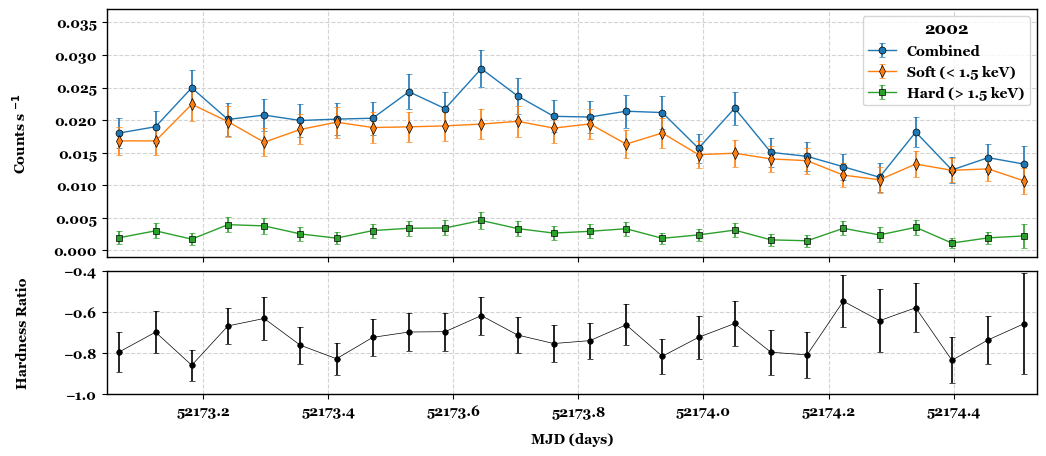

In [51]:
# Plot all AB Aur LCs, 0101440801, binned to 5000s
# = 2/(x_1+x_2 )^2  np.sqrt(x_2^2 σ_(x_1)^2+ x_1^2 σ_(x_2)^2 )
ratio_err = 2/(lc_hard['RATE']+lc_soft['RATE'])**2 * np.sqrt(lc_soft['RATE']**2*lc_hard['ERROR']**2 + lc_hard['RATE']**2*lc_soft['ERROR']**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.075, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x, lc['RATE'], yerr=lc['ERROR'],                lw=1, marker='o', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(x_soft, lc_soft['RATE'], yerr=lc_soft['ERROR'], lw=1, marker='d', ms=5.75, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(x_hard, lc_hard['RATE'], yerr=lc_hard['ERROR'], lw=1, marker='s', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # remove the addition at the end, so full tick values are written
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(-0.001, 0.037)
ax[0].set_ylabel('Counts s $^{-1}$', labelpad=18)
ax[0].legend(title='2002', title_fontsize=12)

ax[1].errorbar(x, (lc_hard['RATE'] - lc_soft['RATE'])/(lc_hard['RATE'] + lc_soft['RATE']), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-1., -0.4)
ax[1].set_xlabel('MJD (days)', labelpad=10)
ax[1].set_ylabel('Hardness Ratio', labelpad=24)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_2002_lc_5000.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

### 1.2ks bin

In [5]:
# Load 2002 Lightcurves
tc = 60*60*24  # convert to days
xmm = 50814.0  # XMM Newton Reference time 

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_lc_1200.lc')
lc = Table(hdul[1].data)[:-1]

for i, col in enumerate(lc.itercols()):
    lc[lc.colnames[i]] = np.mean(col, axis=1)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x = x/tc + xmm

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_soft_1200.lc')
lc_soft = Table(hdul[1].data)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_soft = x_soft/tc + xmm
for i, col in enumerate(lc_soft.itercols()):
    lc_soft[lc_soft.colnames[i]] = np.mean(col, axis=1)

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/ABAur_0101440801_combined_hard_1200.lc')
lc_hard = Table(hdul[1].data)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_hard = x_hard/tc + xmm
for i, col in enumerate(lc_hard.itercols()):
    lc_hard[lc_hard.colnames[i]] = np.mean(col, axis=1)

print(len(lc), len(lc_soft), len(lc_hard), len(x))

108 108 108 108


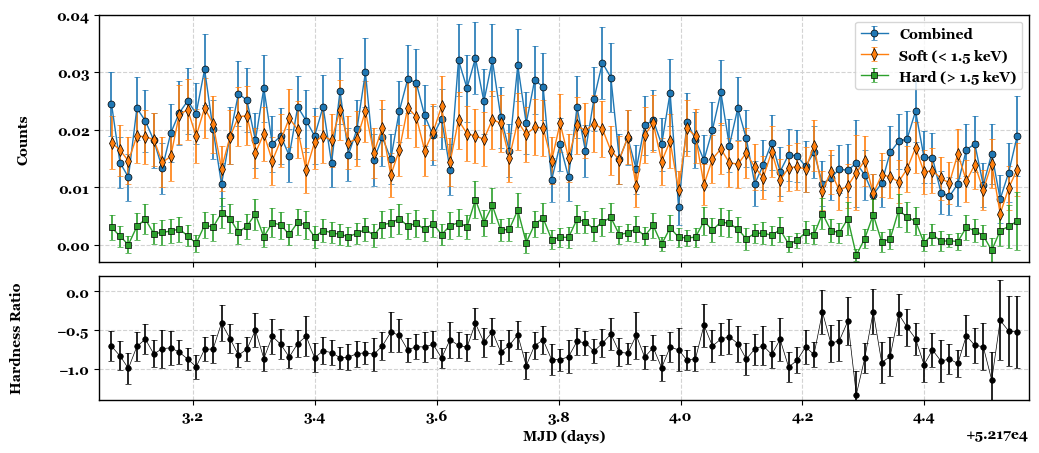

In [6]:
# Plot all AB Aur LCs, 0101440801, binned to 5000s
# = 2/(x_1+x_2 )^2  np.sqrt(x_2^2 σ_(x_1)^2+ x_1^2 σ_(x_2)^2 )
ratio_err = 2/(lc_hard['RATE']+lc_soft['RATE'])**2 * np.sqrt(lc_soft['RATE']**2*lc_hard['ERROR']**2 + lc_hard['RATE']**2*lc_soft['ERROR']**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.075, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x, lc['RATE'], yerr=lc['ERROR'],                lw=1, marker='o', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(x_soft, lc_soft['RATE'], yerr=lc_soft['ERROR'], lw=1, marker='d', ms=5.75, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(x_hard, lc_hard['RATE'], yerr=lc_hard['ERROR'], lw=1, marker='s', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(-0.003, 0.04)
ax[0].set_ylabel('Counts', labelpad=18)
ax[0].legend()

ax[1].errorbar(x, (lc_hard['RATE'] - lc_soft['RATE'])/(lc_hard['RATE'] + lc_soft['RATE']), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-1.4, 0.2)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio', labelpad=24)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_2002_lc_1200.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## 2012 Lightcurves

### 5ks bins

In [19]:
# Plot all SU Aur LCs, 0671960101
tc = 60*60*24  # convert to days
xmm = 50814.0  # XMM Newton Reference time 

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_5000.lc')
lc = Table(hdul[1].data)[:-1]
for i, col in enumerate(lc.itercols()):
    lc[lc.colnames[i]] = np.mean(col, axis=1)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x = x/tc + xmm

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_soft_5000.lc')
lc_soft = Table(hdul[1].data)[:-1]
for i, col in enumerate(lc_soft.itercols()):
    lc_soft[lc_soft.colnames[i]] = np.mean(col, axis=1)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x_soft = x_soft/tc + xmm

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_hard_5000.lc')
lc_hard = Table(hdul[1].data)[:-1]
for i, col in enumerate(lc_hard.itercols()):
    lc_hard[lc_hard.colnames[i]] = np.mean(col, axis=1)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x_hard = x_hard/tc + xmm

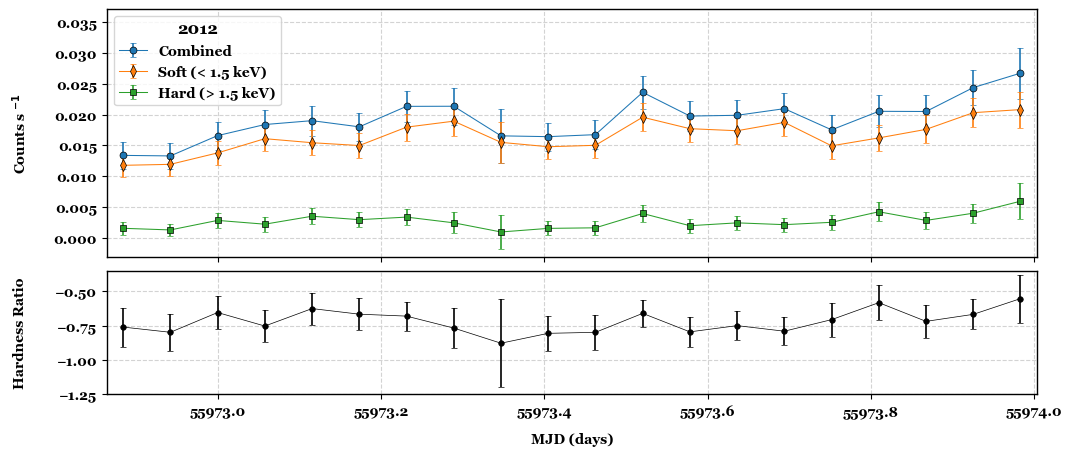

In [46]:
# Plot all SU Aur LCs, 0101440801, 200s bins
ratio_err = 2/(lc_hard['RATE']+lc_soft['RATE'])**2 * np.sqrt(lc_soft['RATE']**2*lc_hard['ERROR']**2 + lc_hard['RATE']**2*lc_soft['ERROR']**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.075, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x, lc['RATE'], yerr=lc['ERROR'],                lw=0.75, marker='o', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(x_soft, lc_soft['RATE'], yerr=lc_soft['ERROR'], lw=0.75, marker='d', ms=5.75, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(x_hard, lc_hard['RATE'], yerr=lc_hard['ERROR'], lw=0.75, marker='s', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # remove the addition at the end, so full tick values are written
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(-0.003, 0.037)
ax[0].set_ylabel('Counts s $^{-1}$', labelpad=18)
ax[0].legend(title='2012', title_fontsize=12)

ax[1].errorbar(x_soft, (lc_hard['RATE'] - lc_soft['RATE'])/(lc_hard['RATE'] + lc_soft['RATE']), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-1.25, -0.35)
ax[1].set_xlabel('MJD (days)', labelpad=10)
ax[1].set_ylabel('Hardness Ratio', labelpad=20)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_2012_lc_5000.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

### 1.2ks bins

In [239]:
# Plot all SU Aur LCs, 0671960101
tc = 60*60*24  # convert to days
xmm = 50814.0  # XMM Newton Reference time 

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_1200.lc')
lc = Table(hdul[1].data)[:-1]
for i, col in enumerate(lc.itercols()):
    lc[lc.colnames[i]] = np.mean(col, axis=1)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x = x/tc + xmm

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_soft_1200.lc')
lc_soft = Table(hdul[1].data)[:-1]
for i, col in enumerate(lc_soft.itercols()):
    lc_soft[lc_soft.colnames[i]] = np.mean(col, axis=1)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x_soft = x_soft/tc + xmm

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/ABAur_combined_lc_hard_1200.lc')
lc_hard = Table(hdul[1].data)[:-1]
for i, col in enumerate(lc_hard.itercols()):
    lc_hard[lc_hard.colnames[i]] = np.mean(col, axis=1)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])[:-1]
x_hard = x_hard/tc + xmm

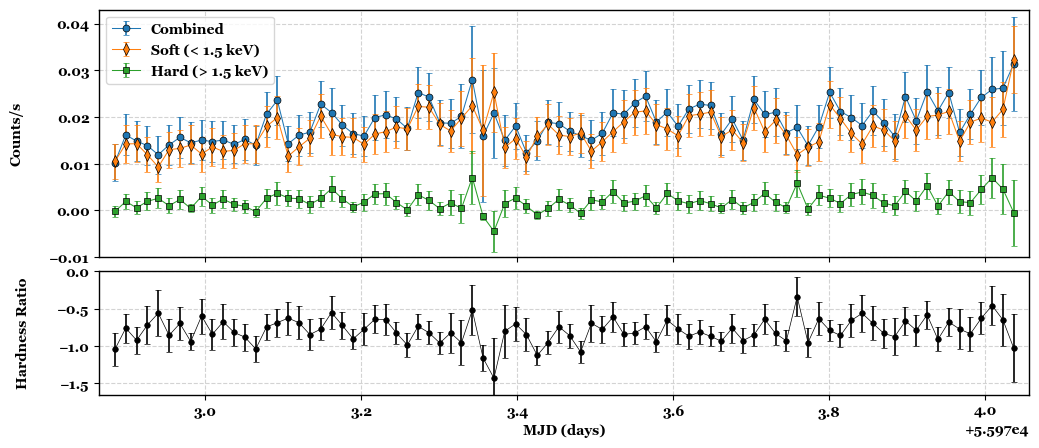

In [240]:
# Plot
ratio_err = 2/(lc_hard['RATE']+lc_soft['RATE'])**2 * np.sqrt(lc_soft['RATE']**2*lc_hard['ERROR']**2 + lc_hard['RATE']**2*lc_soft['ERROR']**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.075, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x, lc['RATE'], yerr=lc['ERROR'],                lw=0.75, marker='o', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(x_soft, lc_soft['RATE'], yerr=lc_soft['ERROR'], lw=0.75, marker='d', ms=5.75, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(x_hard, lc_hard['RATE'], yerr=lc_hard['ERROR'], lw=0.75, marker='s', ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(-0.01, 0.043)
ax[0].set_ylabel('Counts/s', labelpad=18)
ax[0].xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # remove the addition at the end, so full tick values are written
ax[0].legend()

ax[1].errorbar(x_soft, (lc_hard['RATE'] - lc_soft['RATE'])/(lc_hard['RATE'] + lc_soft['RATE']), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-1.65, -0.)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio', labelpad=20)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_2012_lc_1200.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Optical + X-Ray LC

# Comparing Models

In [10]:
all_models = Table.read('model_fits.txt', format='ascii', fast_reader=False, delimiter='\t', guess=False)
all_models[:20].pprint_all()
robrade_2002 = all_models[2:15]
print(robrade_2002)

     Parameter        Value   
------------------- ----------
               2002          .
 Abudances: Robrade          .
            abs1.nH   0.101996
              v1.kT   0.780724
              v2.kT     1.7577
              v3.kT    4.22483
            v1.norm 1.97837E-4
            v2.norm 4.32217E-4
            v3.norm 5.17986E-4
               v1.O    1.38498
              v1.Ne     3.5393
              v1.Mg    2.29256
              v1.Si    1.16947
              v1.Fe    1.18827
               Chi2    1.62162
               2012          .
Abundances: Robrade          .
            abs1.nH   0.124446
              v1.kT    0.61747
              v2.kT   0.991698
Parameter  Value  
--------- --------
  abs1.nH 0.101996
    v1.kT 0.780724
    v2.kT   1.7577
      ...      ...
    v1.Mg  2.29256
    v1.Si  1.16947
    v1.Fe  1.18827
     Chi2  1.62162
Length = 13 rows


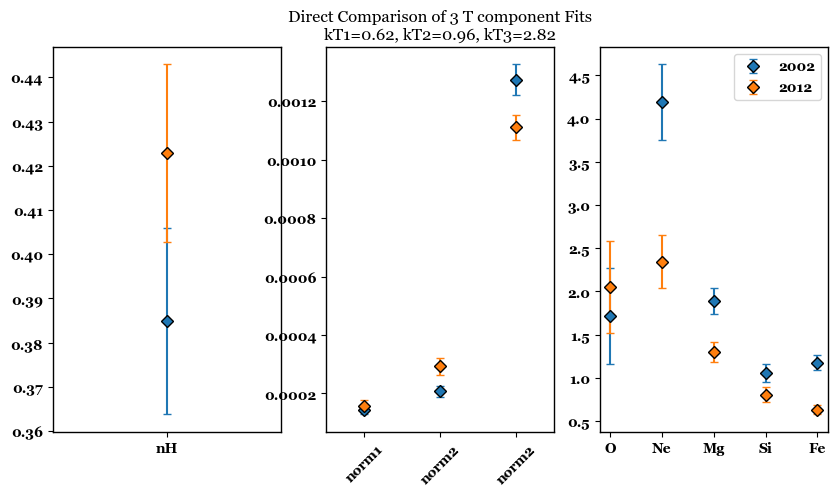

In [11]:
# Comparing 2002 vs 2012, Asplund, 3T
a = [0.384897,1.43135e-4,2.06792e-4,1.27297e-3,1.718,4.189,1.887,1.055,1.176] # 2002, Asplund, 3T, T's locked
e_a = [0.0211278, 1.51525e-5, 1.93015e-5,5.24948e-5,0.555181,0.436373,0.150565,0.109308,0.0877288]
b = [0.422829,1.55455e-4,2.92752e-4,1.1108e-3,2.051,2.344,1.298,0.804,0.627]  # 2012, Asplund, 3T, T's locked
e_b = [0.0200837, 2.05625e-5, 3.01895e-5, 4.31492e-5, 0.532843, 0.308425, 0.118998, 0.0882004, 0.0527734]

x = range(len(a))

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5), gridspec_kw={'wspace':0.2})
ax[0].errorbar(x[:1], a[:1], yerr=e_a[:1], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[0].errorbar(x[:1], b[:1], yerr=e_b[:1], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[0].set_xlim(-0.05, 0.05)
ax[0].set_xticks([0], labels=['nH'])
ax[1].errorbar(x[1:4], a[1:4], yerr=e_a[1:4], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[1].errorbar(x[1:4], b[1:4], yerr=e_b[1:4], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[1].set_xlim(0.5, 3.5)
ax[1].set_xticks([1,2,3], labels=['norm1','norm2','norm2'], rotation=45)
ax[2].errorbar(x[4:], a[4:], yerr=e_a[4:], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2002')
ax[2].errorbar(x[4:], b[4:], yerr=e_b[4:], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2012')
ax[2].set_xticks([4,5,6,7,8],labels=['O','Ne','Mg','Si','Fe'])
plt.legend(loc='upper right')
ax[1].set_title('Direct Comparison of 3 T component Fits\nkT1=0.62, kT2=0.96, kT3=2.82')
plt.show()

14
14
14


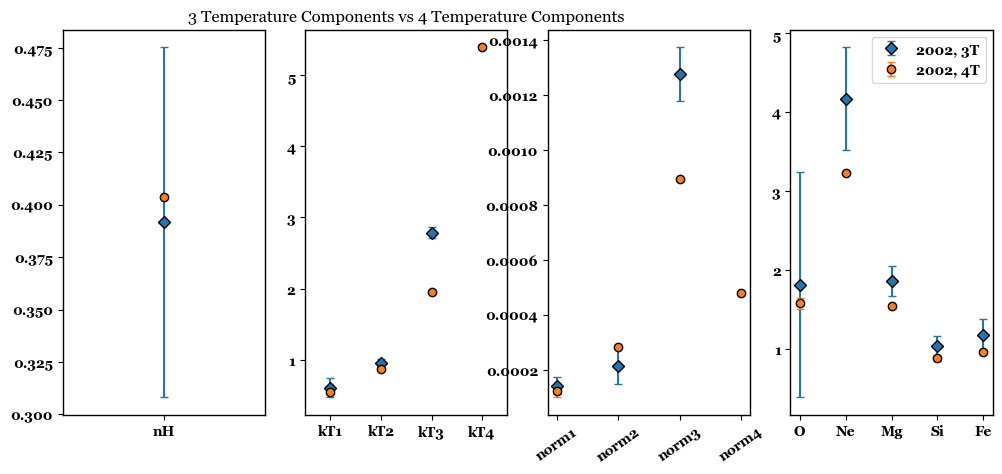

In [41]:
a =   [0.39171,  0.609949,0.951412,    2.7831,    float('nan'),1.41041e-4,2.12765e-4,1.27698e-3, float('nan'),1.81068,4.16607,1.85252,1.03526,1.17649]
e_a = [0.0835608,0.136082,0.0572764,   0.0767677, float('nan'),3.04449e-5,6.51404e-5,9.78322e-5, float('nan'),1.42606,0.649986,0.189309,0.125441,0.200203]
b =   [0.403812, 0.543607,0.86311,     1.9463,    5.38872,1.2024e-4,2.82886e-4,8.93945e-4,4.80419e-4,1.57467,3.22717,1.5347,0.876648,0.952462]
e_b = [float('nan'),0.0164912,0.011941,0.0275718, float('nan'),2.08337e-5,float('nan'),float('nan'),float('nan'),0.0699166,float('nan'),float('nan'),0.0288375,float('nan')]
c = 
e_c = 
d = 
e_d = 

x = range(len(a))
print(len(a))
print(len(b))
print(len(e_b))

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12,5), gridspec_kw={'wspace':0.2})
ax[0].errorbar(x[:1], a[:1], yerr=e_a[:1], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[0].errorbar(x[:1], b[:1], yerr=e_b[:1], marker='o', ls='None', capsize=3, markeredgecolor='k')
ax[0].set_xlim(-0.05, 0.05)
ax[0].set_xticks([0], labels=['nH'])
ax[1].errorbar(x[1:5], a[1:5], yerr=e_a[1:5], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[1].errorbar(x[1:5], b[1:5], yerr=e_b[1:5], marker='o', ls='None', capsize=3, markeredgecolor='k')
ax[1].set_xlim(0.5, 4.5)
ax[1].set_xticks([1,2,3,4], labels=['kT1','kT2','kT3','kT4'])
ax[2].errorbar(x[5:9], a[5:9], yerr=e_a[5:9], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2002')
ax[2].errorbar(x[5:9], b[5:9], yerr=e_b[5:9], marker='o', ls='None', capsize=3, markeredgecolor='k', label='2012')
ax[2].set_xticks([5,6,7,8],labels=['norm1','norm2','norm3','norm4'], rotation=35)
ax[3].errorbar(x[9:], a[9:], yerr=e_a[9:], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2002, 3T')
ax[3].errorbar(x[9:], b[9:], yerr=e_b[9:], marker='o', ls='None', capsize=3, markeredgecolor='k', label='2002, 4T')
ax[3].set_xticks([9,10,11,12,13],labels=['O','Ne','Mg','Si','Fe'])
plt.legend(loc='upper right')
ax[1].set_title('3 Temperature Components vs 4 Temperature Components')
plt.show()

# Spectral Fit Results

## Global Fit Table

In [3]:
# Load results
fit_2002 = Table.read('/Users/woodml/Documents/X-Ray/TaleOfTwoStars/AB Aur/2002_fit_results.txt', format='latex')

fit_2012 = Table.read('/Users/woodml/Documents/X-Ray/TaleOfTwoStars/AB Aur/2012_fit_results.txt', format='latex')

In [4]:
# Create Latex Table

# Create new table, remove uncessary rows
final_fit = vstack([row for row in fit_2002 if ('kT' not in row['Parameter']) and ('norm' not in row['Parameter']) and ('redshift' not in row['Parameter'])])

# Concatentate
final_fit.rename_columns(['Value','e_lower','e_upper'],['value_2002','e_lower_2002','e_upper_2002'])

temp = vstack([row for row in fit_2012 if ('kT' not in row['Parameter']) and ('norm' not in row['Parameter']) and ('redshift' not in row['Parameter'])])

final_fit = hstack([final_fit, temp])
print(final_fit.colnames)

final_fit.remove_columns(['Parameter_2'])
final_fit.rename_columns(['Parameter_1', 'Value','e_lower','e_upper'],['Parameter','value_2012','e_lower_2012','e_upper_2012'])
# final_fit.rename_columns(['Value_3','e_lower_3','e_upper_3'],['value_2012','e_lower_2012','e_upper_2012'])
# final_fit.rename_columns(['Value_4','e_lower_4','e_upper_4'],['value_2012_flare','e_lower_2012_flare','e_upper_2012_flare'])

# Format errors
final_fit['2002'] = [('$' + str(row['value_2002']) + '\pm' + str(row['e_upper_2002']) + '$') if (abs(row['e_lower_2002']) == row['e_upper_2002']) else ('$' + str(row['value_2002']) + '_{' + str(row['e_lower_2002']) + '}^{+' + str(row['e_upper_2002']) +'}$') for row in final_fit]

final_fit['2012'] = [('$' + str(row['value_2012']) + '\pm' + str(row['e_upper_2012']) + '$') if (abs(row['e_lower_2012']) == row['e_upper_2012']) else ('$' + str(row['value_2012']) + '_{' + str(row['e_lower_2012']) + '}^{+' + str(row['e_upper_2012']) +'}$') for row in final_fit]

# Remove extra columns
final_fit = final_fit['Parameter','2002','2012']

# Remove extra elements
final_fit = vstack([row for row in final_fit if (row['Parameter'] != 'v1.C') and (row['Parameter'] != 'v1.He') and (row['Parameter'] != 'v1.N') and (row['Parameter'] != 'v1.S') and (row['Parameter'] != 'v1.Ar') and (row['Parameter'] != 'v1.Ni') and (row['Parameter'] != 'v1.Al') and (row['Parameter'] != 'v1.Ca')])

# Fix Parameter Names
for row in final_fit:
    if row['Parameter'] == 'abs1.nH':
        row['Parameter'] = '$N_{H_1}$'
    elif row['Parameter'] == 'abs2.nH':
        row['Parameter'] = '$N_{H_2}$'
    elif row['Parameter'] == 'v1.EM':
        row['Parameter'] = '$EM_1$'
    elif row['Parameter'] == 'v2.EM':
        row['Parameter'] = '$EM_2$'
    elif row['Parameter'] == 'v3.EM':
        row['Parameter'] = '$EM_3$'
    elif row['Parameter'] == 'v1.T':
        row['Parameter'] = '$T_1$'
    elif row['Parameter'] == 'v2.T':
        row['Parameter'] = '$T_2$'
    elif row['Parameter'] == 'v3.T':
        row['Parameter'] = '$T_3$'
    elif row['Parameter'] == 'v1.O':
        row['Parameter'] = 'C, N, O'
    elif row['Parameter'] == 'v1.Ne':
        row['Parameter'] = 'Ne'
    elif row['Parameter'] == 'v1.Mg':
        row['Parameter'] = 'Mg, Ni'
    elif row['Parameter'] == 'v1.Si':
        row['Parameter'] = 'Si'
    elif row['Parameter'] == 'v1.Fe':
        row['Parameter'] = 'Fe, Ca, Al'

final_fit.pprint_all()
final_fit.write('/Users/woodml/Documents/X-Ray/TaleOfTwoStars/AB Aur/table_global_fit.txt', format='latex', overwrite=True)

['Parameter_1', 'value_2002', 'e_lower_2002', 'e_upper_2002', 'Parameter_2', 'Value', 'e_lower', 'e_upper']
Parameter            2002                     2012         
---------- ------------------------ -----------------------
 $N_{H_1}$ $0.01262_{nan}^{+0.035}$    $0.228736\pm0.01647$
   C, N, O     $1.442725\pm0.35529$    $0.712844\pm0.42461$
        Ne     $0.329368\pm0.24347$    $0.435119\pm0.26701$
    Mg, Ni         $0.187809\pminf$        $0.155814\pminf$
        Si         $0.187809\pminf$        $0.155814\pminf$
Fe, Ca, Al     $0.187809\pm0.04185$    $0.155814\pm0.03802$
     $T_1$   $1.74919_{nan}^{+nan}$ $2.457586_{nan}^{+nan}$
    $EM_1$     $0.049208\pm0.01473$     $0.09495\pm0.07731$
     $T_2$       $9.167699\pm0.277$    $8.943168\pm0.39345$
    $EM_2$     $0.347856\pm0.05193$    $0.268087\pm0.04607$


## Plotting Abundances

In [339]:
f02 = fit_2002
f12 = fit_2012

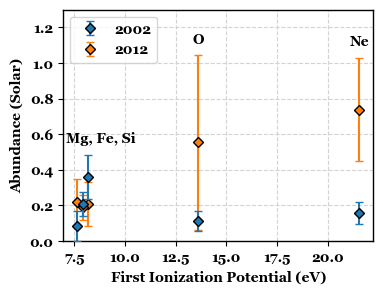

In [342]:
# Plotting abundances
# O, Ne, Mg, Si, Fe

a_f02 = [f02[f02['Parameter']==x]['Value'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]
a_f02_err = [f02[f02['Parameter']==x]['e_upper'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]

a_f12 = [f12[f12['Parameter']==x]['Value'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]
a_f12_err = [f12[f12['Parameter']==x]['e_upper'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]

fips = [13.618, 21.565, 7.646, 8.152, 7.902]

plt.figure(figsize=(4,3))
plt.errorbar(fips, a_f02, yerr=a_f02_err, marker='D', ls='None', ms=5, capsize=3, markeredgecolor='k', label='2002', zorder=4)
plt.errorbar(fips, a_f12, yerr=a_f12_err, marker='D', ls='None', ms=5, capsize=3, markeredgecolor='k', label='2012', zorder=3)
plt.text(8.8, 0.55, 'Mg, Fe, Si', horizontalalignment='center')
plt.text(13.618, 1.11, 'O', horizontalalignment='center')
plt.text(21.565, 1.1, 'Ne', horizontalalignment='center')
plt.legend(loc='upper left')
plt.ylim(0, 1.3)
plt.xlabel('First Ionization Potential (eV)')
plt.ylabel('Abundance (Solar)')
plt.grid('major','both',c='lightgray',ls='--', zorder=0)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_fip.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# RGS

Filename: /Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/combinedspectra.ds
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  SPECTRUM      1 BinTableHDU     50   3600R x 5C   [I, J, I, E, E]   
None


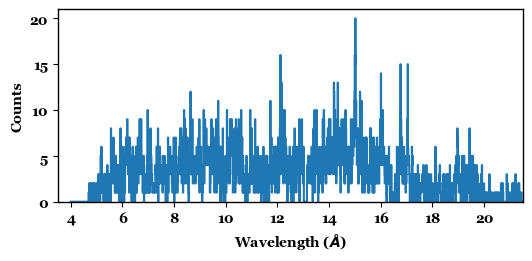

Filename: /Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/combinedspectra.ds
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  SPECTRUM      1 BinTableHDU     50   3600R x 5C   [I, J, I, E, E]   
None


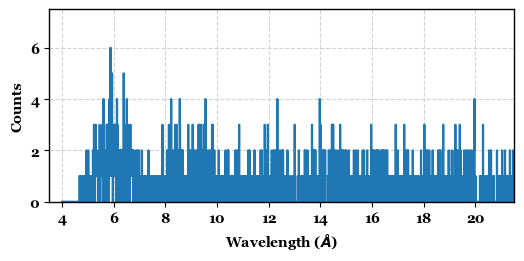

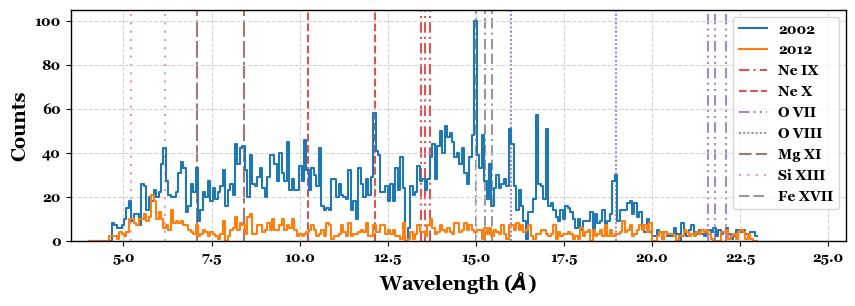

In [344]:
# Load Data
hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0101440801/combinedspectra.ds')
print(hdul.info())

hdr = hdul[1].header

rgs2 = Table(hdul[1].data)

x = np.arange(hdr['TCRVL1'], hdr['TCRVL1']+hdr['TCDLT1']*hdr['TLMAX1'], hdr['TCDLT1'])

x = x[x< 23]
rgs2 = rgs2[:len(x)]

# plot 2002
plt.figure(figsize=(6,2.5))
plt.step(x, rgs2['COUNTS'])
plt.xlim(3.5, 21.5)
plt.ylim(0,21)
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Counts')
plt.show()

# Load 2012 data
hdul = fits.open('/Users/woodml/Observing/XMM-Newton/AB_Aur/0671960101/combinedspectra.ds')
print(hdul.info())

hdr = hdul[1].header

rgs12 = Table(hdul[1].data)

x12 = np.arange(hdr['TCRVL1'], hdr['TCRVL1']+hdr['TCDLT1']*hdr['TLMAX1'], hdr['TCDLT1'])

x12 = x12[x12< 23]
rgs12 = rgs12[:len(x)]

# plot 2012
plt.figure(figsize=(6, 2.5))
plt.step(x12, rgs12['COUNTS'])
plt.xlim(3.5, 21.5)
plt.ylim(0, 7.5)
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Counts')
plt.grid('both','major',c='lightgray',ls='--', zorder=0)
plt.show()

# Plot both datasets
b = 7
plt.figure(figsize=(10, 3))
plt.step([np.mean(x[i:i+b]) for i in range(0,len(x),b)], [np.sum(rgs2['COUNTS'][i:i+b]) for i in range(0,len(x),b)], label='2002')
plt.step([np.mean(x12[i:i+b]) for i in range(0,len(x12),b)], [np.sum(rgs12['COUNTS'][i:i+b]) for i in range(0,len(x),b)], label='2012')

plt.vlines([13.447, 13.55, 13.699],    0, 200, 'C3', ls= (0, (5, 2, 1, 2)), alpha=0.8, zorder=0, label='Ne IX')
plt.vlines([12.13, 10.24],             0, 200, 'C3', ls='--', alpha=0.8, zorder=0, label='Ne X')
plt.vlines([21.60, 21.80, 22.10],      0, 200, 'C4', ls= (0, (5, 2, 1, 2, 1, 2)), alpha=0.8, zorder=0, label='O VII')
plt.vlines([16.00, 18.97],             0, 200, 'C4', ls= (0, (1, 1)), alpha=0.8, zorder=0, label='O VIII')
plt.vlines([8.42, 7.10],               0, 200, 'C5', ls=(2,(8,2)), alpha=0.8, zorder=0, label='Mg XI')
plt.vlines([6.18, 5.22],               0, 200, 'C6', ls= (0, (1, 3)), alpha=0.8, zorder=0, label='Si XIII')
plt.vlines([15.015, 15.262, 15.450],   0, 200, 'C7', ls= (0, (5, 2, 5, 2, 1, 2)), alpha=0.8, zorder=0, label='Fe XVII')

plt.xlim(3.5, 25.5)
plt.ylim(0, 105)
plt.xlabel(r'Wavelength ($\AA$)', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.grid('both','major',c='lightgray',ls='--', zorder=0)
plt.legend()
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_rgs_spectra.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# Optical Halpha

In [4]:
import string
import re

import numpy as np

import astropy.io.fits as fits
from astropy.wcs import WCS
from specutils import Spectrum1D

class IrafFormatError(Exception):
    '''
    '''
    pass

'''
Missing important things
onedspec format
LTM, CD keywords, CDELT
'''

### implement several possible dispersion functions
def polynomial(func, spec):
    '''Evaluate polynomial dispersion functions
    
    IRAF defines two possible polynomials: Chebyshev and Legendre
    
    Parameters
    ----------
    func : function
        Possible functions are Chebyshev and Legendre
    spec : list of strings
        This is split from the "specN= A B C ..." string in a fits header,
        that defines the WCS to use
    
    Returns
    -------
    pmin, pmax: integer
        min and max coordinate descibed by this dispersion relation
        in physical pixles
    result : np.array
       wavelengths calculated form the dispersion relation
    '''
    order = int(spec.pop(0))
    pmin = int(float(spec.pop(0)))
    pmax = int(float(spec.pop(0)))
    n = np.linspace(-1,1,pmax-pmin+1)
    temp = np.zeros((pmax-pmin+1, order), dtype = float)
    temp[:,0] = 1.
    temp[:,1] = n
    for i in np.arange(2,order):
        temp[:,i] = func(n, i, temp)
    for i in np.arange(0,order):
        temp[:,i] = float(spec.pop(0)) * temp[:,i]
    return pmin, pmax, temp.sum(axis=1)

def chebyshev(n, i, temp):
    '''Iterative definition of Chebyshev polynomial
    
    Implented here from the iraf.noao.onddspec documentation
    see http://iraf.net/irafdocs/specwcs.php
    
    Parameters
    ----------
    n : np.array
        input normalized coordinate array from -1..1
    i : float or integer
        degree of current iteration
    temp : np.array of dimension (n,i)
        temporary array holding previous iterations
    '''
    return 2. * n * temp[:,i-1] - temp[:,i-2]

def legendre(n, i, temp):
    '''Iterative definition of Legendre polynomial
    
    Implented here from the iraf.noao.onddspec documentation
    see http://iraf.net/irafdocs/specwcs.php
    
    Parameters
    ----------
    n : np.array
        input normalized coordinate array from -1..1
    i : float or integer
        degree of current iteration
    temp : np.array of dimension (n,i)
        temporary array holding previous iterations
    '''
    return ((2*i-1)*n*temp[:,i-1]-(i-1)*temp[:,i-2])/i

def linear_spline(spec):
    '''Evaluate linear spline dispersion function
    
    Parameters
    ----------
    spec : list of strings
        This is split from the "specN= A B C ..." string in a fits header,
        that defines the WCS to use
    
    Returns
    -------
    pmin, pmax: integer
        min and max coordinate descibed by this dispersion relation
        in physical pixles
    result : np.array
       wavelengths calculated fomr the dispersion relation
    '''
    npieces = int(spec.pop(0))
    pmin = int(float(spec.pop(0)))
    pmax = int(float(spec.pop(0)))
    s = np.linspace(0, npieces, pmax-pmin+1)
    temp = np.zeros((pmax-pmin+1), dtype = np.float)
    for i in np.arange(0,npieces+1):
        weight = np.clip(1.-np.abs(i-s), 0., 1.)
        temp += weight * float(spec.pop(0))
    return pmin, pmax, temp

def cubic_spline(spec):
    '''Evaluate linear spline dispersion function
    
    Parameters
    ----------
    spec : list of strings
        This is split from the "specN= A B C ..." string in a fits header,
        that defines the WCS to use
    
    Returns
    -------
    pmin, pmax: integer
        min and max coordinate descibed by this dispersion relation
        in physical pixles
    result : np.array
       wavelengths calculated fomr the dispersion relation
    '''
    npieces = int(spec.pop(0))
    pmin = int(float(spec.pop(0)))
    pmax = int(float(spec.pop(0)))
    s = np.linspace(0, npieces, pmax-pmin+1)
    temp = np.zeros((pmax-pmin+1), dtype = np.float)
    for i in np.arange(0,npieces+3):
        c_i = float(spec.pop(0))
        a = np.linspace(0, 1, (pmax-pmin+1)/npieces)
        b = 1. - a
        ind = (s>=i-3) & (s<=i-2)
        if np.sum(ind) > 0: temp[ind] += c_i * b**3
        ind = (s>=i-2) & (s<=i-1)
        if np.sum(ind) > 0: temp[ind] += c_i * (1.+3*b*(1+a*b))
        ind = (s>=i-1) & (s<=i)
        if np.sum(ind) > 0: temp[ind] += c_i * (1.+3*a*(1+a*b))
        ind = (s>=i) & (s<=i+1)
        if np.sum(ind) > 0: temp[ind] += c_i * a**3
    return pmin, pmax, temp



def wave_multispec(header):
    '''calculate wavelength array from MULTISPEC header
    
    This function extracts information from the header of a fits file that
    contains spectral data. From this information, the wavelength array is 
    calculated.
    
    ..note: While some checking on the fits header keywords is done, the
        implementation is not complete. Also, many telescopes use non-standard
        keywords or do not write required values. Be wary!
    
    Parameters
    ----------
    header : astropy.io.fits.header.Header
        header of fits file
    
    Returns
    -------
    wave : np.array
        wavelength array in the format specified in the header. Depending on the 
        header keywords, this can be one or two dimensional.
    '''
    wave = np.empty((header['NAXIS2'], header['NAXIS1']), dtype= float)
    wave[:] = np.nan 
    head = header['WAT*']
    formstring = []
    for i in range(len(head)):
        formstring.append(head[i])
    formstring = "".join(formstring)
    formstring = formstring.replace('= ', '=')
    formstring = formstring.replace(' =', '=')
    specs = re.findall(r'spec[0-9]+="[0-9eE .+-]*"', formstring)
    for spec in specs:
        spec=spec[4:].replace('=',' ').replace('"','')
        #specN = ap beam dtype w1 dw nw z aplow aphigh [functions_i]
        #    0    1  2     3    4  5  6 7   8     9     10:
        spec = spec.split()
        N = int(spec.pop(0))
        ap = spec.pop(0)
        beam = spec.pop(0)
        dtype = int(spec.pop(0))
        w1 = float(spec.pop(0))
        dw = float(spec.pop(0))
        nw = int(spec.pop(0))
        z = float(spec.pop(0))
        aplow = float(spec.pop(0))
        aphigh = float(spec.pop(0))
        if dtype == -1:   # no dispersion solution in header
            pass
        elif dtype == 0:  # linear dispersion
            stop = w1 + dw * (nw +0.5)
            wave[N-1,:] = np.arange(w1, stop, dw)/(1.+z)
        elif dtype == 1:  # log-linear dispersion
            stop = w1 + dw * (nw +0.5)
            wave[N-1,:] = 10.**np.arange(w1, stop, dw)/(1.+z)
        elif dtype == 2:  # non-linear dispersion
            wave[N-1,:] = 0
            while len(spec) > 0:
                weight = float(spec.pop(0))
                offset = float(spec.pop(0))
                func = int(spec.pop(0))
                if func == 1:
                    pmin, pmax, thiswave = polynomial(chebyshev, spec)
                elif func == 2:
                    pmin, pmax, thiswave = polynomial(legendre, spec)
                elif func == 3:
                    pmin, pmax, thiswave = linear_spline(spec)
                elif func == 4:
                    pmin, pmax, thiswave = cubic_spline(spec)
                elif func == 5:
                    # TBD: pixel coordinate array
                    raise NotImplementedError
                elif func == 6:
                    #TBD: sampled coordinate array
                    raise NotImplementedError
                else:
                    raise IrafFormatError('File does not conform to IRAF format - non-linear of dispersion function must be [1,2,3,4,5,6]')
                wave[N-1,pmin-1:pmax] += weight * (offset + thiswave)
            wave[N-1,:] = wave[N-1,:]/(1.+z)

        else:
            raise IrafFormatError('File does not conform to IRAF format - type of dispersion function must be [-1,0,1,2]')
    return wave

def wave_1dspec(header):
    '''calculate wavelength array from header for 1 dim WCS
    
    This function extracts information from the header of a fits file that
    contains spectral data. From this information, the wavelength array is 
    calculated.
    
    Parameters
    ----------
    header : astropy.io.fits.header.Header
        header of fits file
    
    Returns
    -------
    wave : np.array
        wavelength array in the format specified in the header.
    '''
    w = WCS(header)
    return w.wcs_pix2world(np.arange(header['NAXIS1'])[:,np.newaxis], 0).squeeze()


def make_IRAF_wave(header):
    old_STRIP_HEADER_WHITESPACE = fits.conf.strip_header_whitespace 
    try:
        fits.conf.strip_header_whitespace = False
        if header['NAXIS'] ==2:
            if header['WCSDIM'] == 2:
                if header['CTYPE1'] == 'MULTISPE' or header['CTYPE2'] == 'MULTISPE':
                    if header['CTYPE1'] == 'MULTISPE' and header['CTYPE2'] == 'MULTISPE':
                        wave = wave_multispec(header)
                    else:
                        raise IrafFormatError('File does not conform to IRAF format - multispec spectra must have CTYPE1 and CTYPE2 = MULTISPE')
            else:
                raise NotImplementedError
        elif header['NAXIS'] ==1:
            wave = wave_1dspec(header)
        else:
            raise NotImplementedError
        return wave
    finally:
        fits.conf.strip_header_whitespace = old_STRIP_HEADER_WHITESPACE
        pass

def read_IRAF_spec(filename):
    '''
    Read spectrum in IRAF WCS=MULTISPEC form
  
    Parameters
    ----------
    filename : string
  
    Returns
    -------
    spec : Spectrum1D
    To-Do
    -----
    - take care of units
    - look for uncertainties
    '''

    hdus = fits.open(filename)
    try:
        flux = hdus[0].data
        meta = hdus[0].header
        wave = make_IRAF_wave(meta)

    finally:
        hdus.close()

    # spec = Spectrum1D.from_array(wave, flux, meta = meta)
    print(wave.shape)
    print(flux.shape)
    all_spec = []
    for i in range(wave.shape[0]):
        all_spec.append(Spectrum1D(spectral_axis=wave[i]*u.Angstrom, flux=flux[i] * u.Jy))
    return all_spec

Filename: /Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/AB-Aur_2012-02-15_07h33m17s_cb.spec.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   (2304, 51)   float32   
(51, 2304)
(51, 2304)


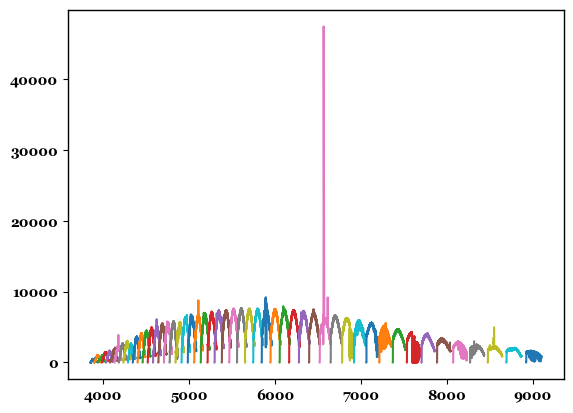

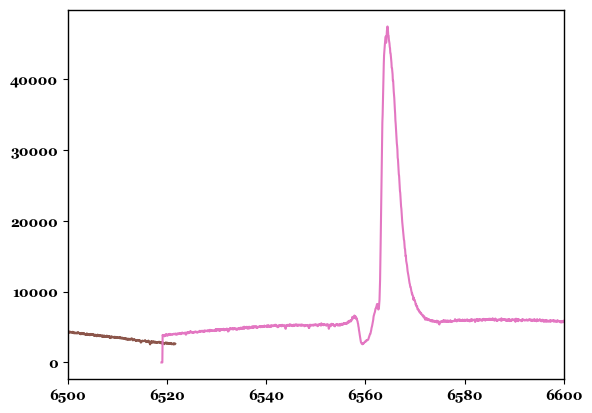

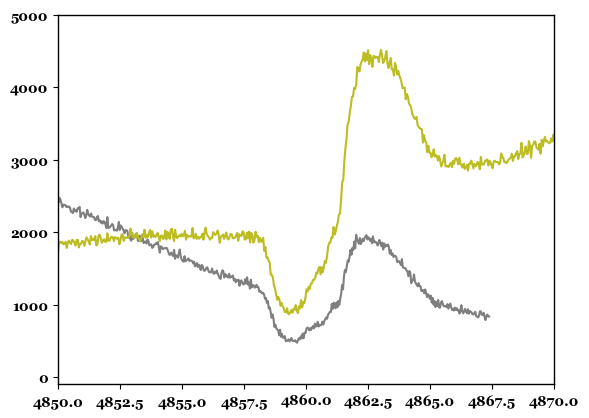

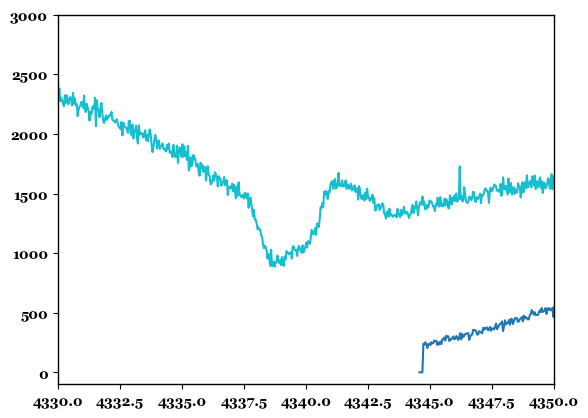

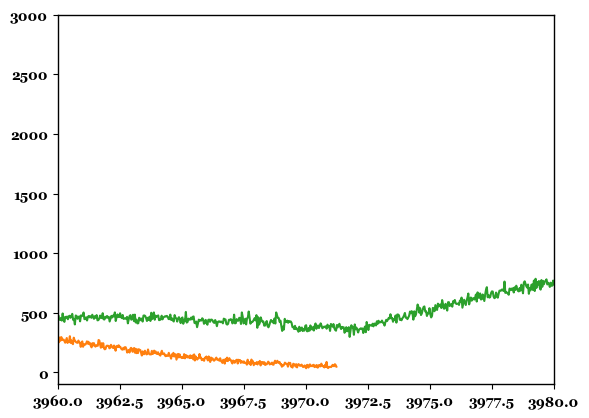

In [297]:
file = '/Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/AB-Aur_2012-02-15_07h33m17s_cb.spec.fits'

hdul = fits.open(file)
hdul.info()

hdr = hdul[0].header


all_spec = read_IRAF_spec(file)

plt.figure()
for spec in all_spec:
    plt.plot(spec.spectral_axis, spec.flux)
plt.show()

# Halpha
plt.figure()
for spec in all_spec:
    plt.plot(spec.spectral_axis, spec.flux)
plt.xlim(6500, 6600)
plt.show()

# Ca H & K
plt.figure()
for spec in all_spec:
    plt.plot(spec.spectral_axis, spec.flux)
plt.xlim(4850, 4870)
plt.ylim(-100, 5000)
plt.show()

# He I
plt.figure()
for spec in all_spec:
    plt.plot(spec.spectral_axis, spec.flux)
plt.xlim(4330, 4350)
plt.ylim(-100, 3000)
plt.show()

# He I
plt.figure()
for spec in all_spec:
    plt.plot(spec.spectral_axis, spec.flux)
plt.xlim(3960, 3980)
plt.ylim(-100, 3000)
plt.show()

36
17
18
9


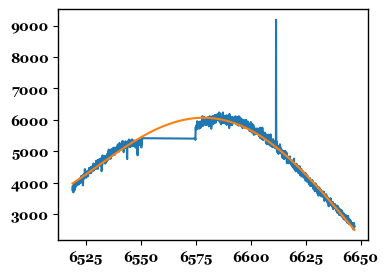

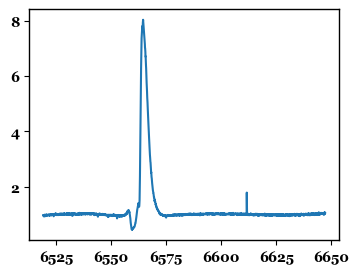

In [323]:
# 1. Identify orders w/ H lines
halpha = 6562.8
hbeta  = 4861
hgamma = 4340

[print(i) for i in range(len(all_spec)) if any(abs(all_spec[i].spectral_axis.to('Angstrom').value-halpha) < 1) ]
[print(i) for i in range(len(all_spec)) if any(abs(all_spec[i].spectral_axis.to('Angstrom').value-hbeta) < 1) ]
[print(i) for i in range(len(all_spec)) if any(abs(all_spec[i].spectral_axis.to('Angstrom').value-hgamma) < 1) ]

alpha_wave = all_spec[36].spectral_axis.to('Angstrom').value[4:]
alpha_flux = all_spec[36].flux.value[4:]
beta_wave = all_spec[18].spectral_axis.to('Angstrom').value[4:]
beta_flux = all_spec[18].flux.value[4:]
gamma_wave = all_spec[9].spectral_axis.to('Angstrom').value
gamma_flux = all_spec[9].flux.value

# 2. Continuum Correct
#    a. Mask Line
line_mask = [True if abs(x-halpha) > 12 else False for x in alpha_wave]

ha_cont = np.polyfit(alpha_wave[line_mask], alpha_flux[line_mask], 4)

plt.figure(figsize=(4,3))
plt.plot(alpha_wave[line_mask], alpha_flux[line_mask])
plt.plot(alpha_wave, np.polyval(ha_cont, alpha_wave))
plt.show()

alpha_flux = alpha_flux/np.polyval(ha_cont, alpha_wave)

plt.figure(figsize=(4,3))
plt.plot(alpha_wave, alpha_flux)
plt.show()

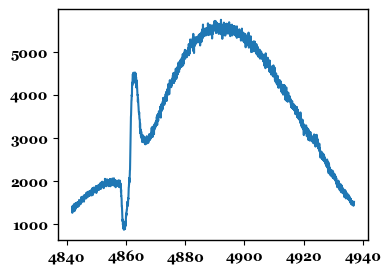

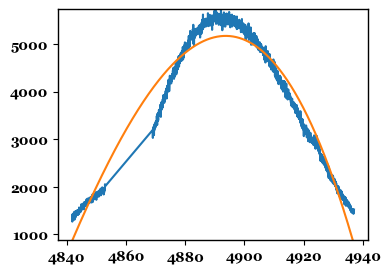

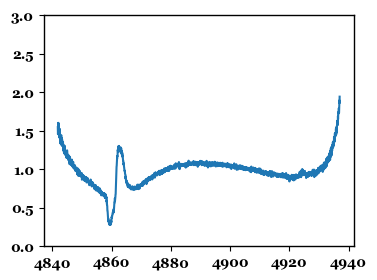

In [353]:
# Hbeta
beta_wave = all_spec[18].spectral_axis.to('Angstrom').value[4:]
beta_flux = all_spec[18].flux.value[4:]

plt.figure(figsize=(4,3))
plt.plot(beta_wave, beta_flux)
plt.show()

#    a. Mask Line
line_mask = [True if abs(x-hbeta) > 8 else False for x in beta_wave]

hb_cont = np.polyfit(beta_wave[line_mask], beta_flux[line_mask], 3)

plt.figure(figsize=(4,3))
plt.plot(beta_wave[line_mask], beta_flux[line_mask])
plt.plot(beta_wave, np.polyval(hb_cont, beta_wave))
plt.ylim(np.min(beta_flux), np.max(beta_flux))
plt.show()

beta_flux = beta_flux/np.polyval(hb_cont, beta_wave)

plt.figure(figsize=(4,3))
plt.plot(beta_wave, beta_flux)
plt.ylim(0,3)
plt.show()

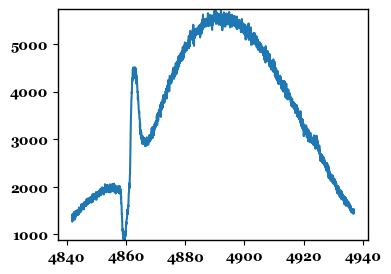

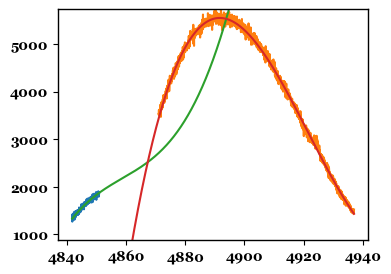

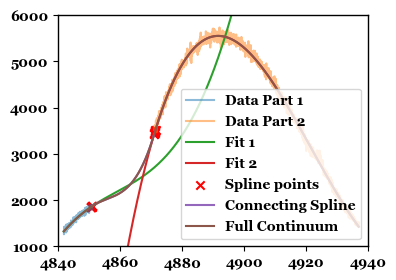

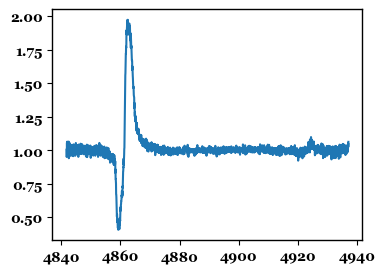

In [329]:
# beta
beta_wave = all_spec[18].spectral_axis.to('Angstrom').value[4:]
beta_flux = all_spec[18].flux.value[4:]

plt.figure(figsize=(4,3))
plt.plot(beta_wave, beta_flux)
plt.ylim(np.min(beta_flux), np.max(beta_flux))
plt.show()

line_mask = [True if abs(x-hbeta) < 10 else False for x in beta_wave]
line_mask1 = [True if (hbeta - x) > 10 else False for x in beta_wave]
line_mask2 = [True if (x - hbeta) > 10 else False for x in beta_wave]

hb_cont1 = np.polyfit(beta_wave[line_mask1], beta_flux[line_mask1], 3)
hb_cont2 = np.polyfit(beta_wave[line_mask2], beta_flux[line_mask2], 3)


plt.figure(figsize=(4,3))
plt.plot(beta_wave[line_mask1], beta_flux[line_mask1])
plt.plot(beta_wave[line_mask2], beta_flux[line_mask2])
plt.plot(beta_wave, np.polyval(hb_cont1, beta_wave))
plt.plot(beta_wave, np.polyval(hb_cont2, beta_wave))
plt.ylim(np.min(beta_flux), np.max(beta_flux))
plt.show()

x1 = np.concatenate([beta_wave[line_mask1][-10:], beta_wave[line_mask2][:11]])
y1 = np.concatenate([np.polyval(hb_cont1, beta_wave[line_mask1])[-10:], np.polyval(hb_cont2, beta_wave[line_mask2])[:11]])
# y1 = np.concatenate([beta_flux[line_mask1][-10:], beta_flux[line_mask2][:11]])
spline = scipy.interpolate.CubicSpline(x1, y1, bc_type='natural')
# spline = np.polyfit(x1, y1, 2)

hb_cont = np.concatenate([np.polyval(hb_cont1, beta_wave[line_mask1]), spline(beta_wave[line_mask]), np.polyval(hb_cont2, beta_wave[line_mask2])])

plt.figure(figsize=(4,3))
plt.plot(beta_wave[line_mask1], beta_flux[line_mask1], alpha=0.5, label='Data Part 1')
plt.plot(beta_wave[line_mask2], beta_flux[line_mask2], alpha=0.5, label='Data Part 2')
plt.plot(beta_wave, np.polyval(hb_cont1, beta_wave), label='Fit 1')
plt.plot(beta_wave, np.polyval(hb_cont2, beta_wave), label='Fit 2')
plt.scatter(x1, y1, marker='x', c='r', label='Spline points')
plt.plot(beta_wave[line_mask], spline(beta_wave[line_mask]), label='Connecting Spline')
plt.plot(beta_wave, hb_cont, label='Full Continuum')
plt.xlim(4840, 4940)
plt.ylim(1000, 6000)
plt.legend()
plt.show()

beta_flux = beta_flux/hb_cont

plt.figure(figsize=(4,3))
plt.plot(beta_wave, beta_flux)
plt.show()

#    b. Fit polynomial
#    c. Remove polynomial

# 3. Plot nice

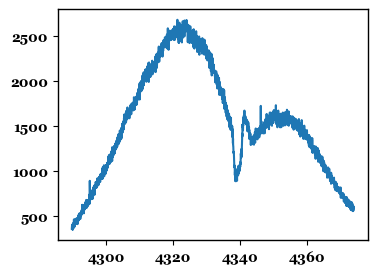

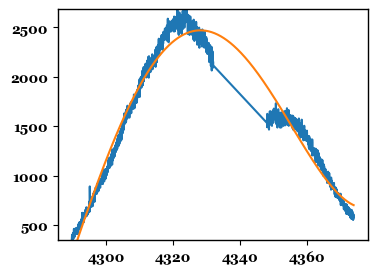

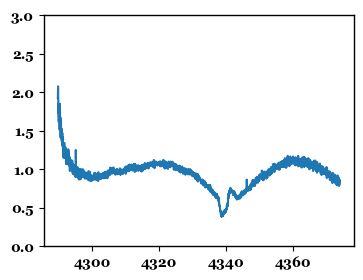

In [348]:
# Hgamma
gamma_wave = all_spec[9].spectral_axis.to('Angstrom').value[4:]
gamma_flux = all_spec[9].flux.value[4:]

plt.figure(figsize=(4,3))
plt.plot(gamma_wave, gamma_flux)
plt.show()

#    a. Mask Line
line_mask = [True if abs(x-hgamma) > 8 else False for x in gamma_wave]

hg_cont = np.polyfit(gamma_wave[line_mask], gamma_flux[line_mask], 4)

plt.figure(figsize=(4,3))
plt.plot(gamma_wave[line_mask], gamma_flux[line_mask])
plt.plot(gamma_wave, np.polyval(hg_cont, gamma_wave))
plt.ylim(np.min(gamma_flux), np.max(gamma_flux))
plt.show()

gamma_flux = gamma_flux/np.polyval(hg_cont, gamma_wave)

plt.figure(figsize=(4,3))
plt.plot(gamma_wave, gamma_flux)
plt.ylim(0,3)
plt.show()

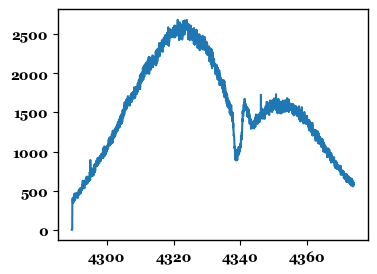

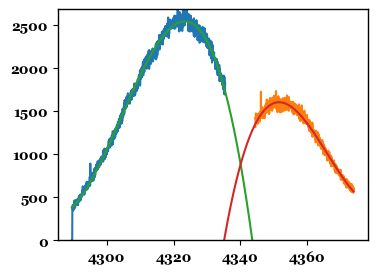

[4335.14012245 4335.17671361 4335.21330206 4335.24988779 4335.28647081
 4335.32305112 4335.35962871 4335.39620359 4335.43277576 4335.46934521
 4344.52618764 4344.56207149 4344.5979526  4344.63383096 4344.66970657
 4344.70557943 4344.74144954 4344.7773169  4344.81318152 4344.84904338
 4344.8849025 ] [1777.67736721 1772.50527287 1767.31372738 1762.10271931 1756.8722229
 1751.62222481 1746.35270023 1741.06363297 1735.7550087  1730.42679882
 1351.58503342 1354.30400658 1357.00631523 1359.69198704 1362.36105728
 1365.01355553 1367.64951229 1370.26896    1372.87192726 1375.4584465
 1378.02855301]


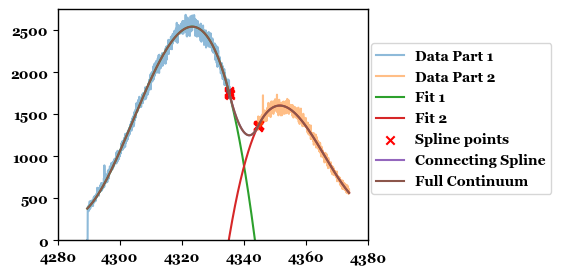

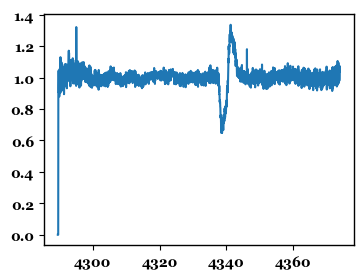

In [330]:
# Hgamma
gamma_wave = all_spec[9].spectral_axis.to('Angstrom').value[4:]
gamma_flux = all_spec[9].flux.value[4:]

plt.figure(figsize=(4,3))
plt.plot(gamma_wave, gamma_flux)
plt.show()

#    a. Mask Line
line_mask = [True if abs(x-hgamma) < 4.5 else False for x in gamma_wave]
line_mask1 = [True if (hgamma - x) > 4.5 else False for x in gamma_wave]
line_mask2 = [True if (x - hgamma) > 4.5 else False for x in gamma_wave]

hg_cont1 = np.polyfit(gamma_wave[line_mask1], gamma_flux[line_mask1], 3)
hg_cont2 = np.polyfit(gamma_wave[line_mask2], gamma_flux[line_mask2], 3)

plt.figure(figsize=(4,3))
plt.plot(gamma_wave[line_mask1], gamma_flux[line_mask1])
plt.plot(gamma_wave[line_mask2], gamma_flux[line_mask2])
plt.plot(gamma_wave, np.polyval(hg_cont1, gamma_wave))
plt.plot(gamma_wave, np.polyval(hg_cont2, gamma_wave))
plt.ylim(np.min(gamma_flux), np.max(gamma_flux))
plt.show()

x1 = np.concatenate([gamma_wave[line_mask1][-10:], gamma_wave[line_mask2][:11]])
y1 = np.concatenate([np.polyval(hg_cont1, gamma_wave[line_mask1])[-10:], np.polyval(hg_cont2, gamma_wave[line_mask2])[:11]])

print(x1, y1)

spline = scipy.interpolate.CubicSpline(x1, y1, bc_type='natural')

hg_cont = np.concatenate([np.polyval(hg_cont1, gamma_wave[line_mask1]), spline(gamma_wave[line_mask]), 
                          np.polyval(hg_cont2, gamma_wave[line_mask2])])

plt.figure(figsize=(4,3))
plt.plot(gamma_wave[line_mask1], gamma_flux[line_mask1], alpha=0.5, label='Data Part 1')
plt.plot(gamma_wave[line_mask2], gamma_flux[line_mask2], alpha=0.5, label='Data Part 2')
plt.plot(gamma_wave, np.polyval(hg_cont1, gamma_wave), label='Fit 1')
plt.plot(gamma_wave, np.polyval(hg_cont2, gamma_wave), label='Fit 2')
plt.scatter(x1, y1, marker='x', c='r', label='Spline points')
plt.plot(gamma_wave[line_mask], spline(gamma_wave[line_mask]), label='Connecting Spline')
plt.plot(gamma_wave, hg_cont, label='Full Continuum')
plt.xlim(4280, 4380)
plt.ylim(0, 2750)
plt.legend(loc=(1.01, 0.2))
plt.show()

gamma_flux = gamma_flux/hg_cont

plt.figure(figsize=(4,3))
plt.plot(gamma_wave, gamma_flux)
plt.show()

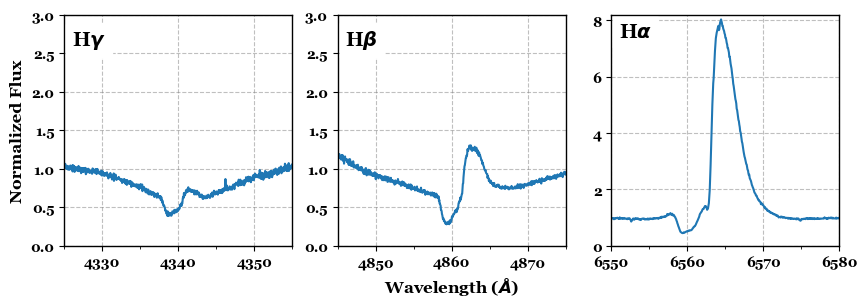

In [357]:
# Big Plot

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
ax[0].plot(gamma_wave, gamma_flux)
ax[1].plot(beta_wave, beta_flux)
ax[2].plot(alpha_wave, alpha_flux)
# ax[0].vlines([hgamma], 0, 3, 'k', '--', zorder=0)
# ax[1].vlines([hbeta], 0, 3, 'k', '--', zorder=0) 

ax[0].text(4326, 2.6, r'H$\gamma$', fontsize=14, backgroundcolor='w')
ax[1].text(4846, 2.6, r'H$\beta$', fontsize=14, backgroundcolor='w')
ax[2].text(6551, 7.4, r'H$\alpha$', fontsize=14, backgroundcolor='w')

ax[0].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[1].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[2].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)

ax[0].set_xlim(4325, 4355)
ax[0].set_ylim(0, 3)
ax[1].set_xlim(4845, 4875)
ax[1].set_ylim(0, 3)
ax[2].set_xlim(6550, 6580)
ax[2].set_ylim(0, 8.2)

ax[0].set_xticks([4330, 4340, 4350])
ax[0].set_xticklabels(['4330', '4340', '4350'])
ax[0].set_xticks([4325, 4335, 4345, 4355], minor=True)

ax[1].set_xticks([4850, 4860, 4870])
ax[1].set_xticklabels(['4850', '4860', '4870'])
ax[1].set_xticks([4845, 4855, 4865, 4875], minor=True)

ax[2].set_xticks([ 6555, 6565, 6575], minor=True)

ax[0].set_ylabel('Normalized Flux', fontsize=12)
ax[1].set_xlabel(r'Wavelength ($\AA$)', fontsize=12)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_h.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [293]:
files = glob.glob('/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/*.fits')
files.sort(reverse=True)
print(files)
print(len(files))

['/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0062.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0061.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0059.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0058.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0057.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0056.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0053.ABAur.ms.fits', '/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/0051.ABAur.ms.fits']
8


2681 2681
2681 2681
2681 2681
2681 2681
2681 2681
2681 2681
2682 2681
2682 2681


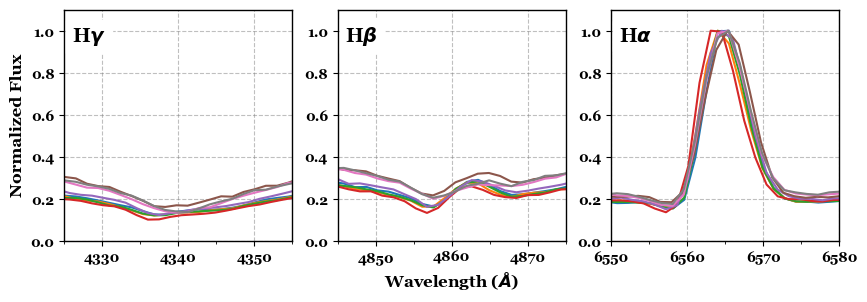

In [295]:
# Big Plot

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

for file in files:
    hdul = fits.open(file)
    hdr = hdul[0].header
    data = hdul[0].data
    flux = data[0][0]
    
    wv = np.arange(hdr['CRVAL1'], hdr['CRVAL1']+(hdr['CD1_1']*hdr['NAXIS1']), hdr['CD1_1'])
    print(len(wv), len(flux))
    if len(wv) > len(flux): wv = wv[:-1]
    

    ax[0].plot(wv, flux/np.max(flux), label=round(Time(hdr['MJD'], format='mjd').mjd,4))
    ax[1].plot(wv, flux/np.max(flux), label=round(Time(hdr['MJD'], format='mjd').mjd,4))
    ax[2].plot(wv, flux/np.max(flux), label=round(Time(hdr['MJD'], format='mjd').mjd,4))
    

ax[0].text(4326, 0.95, r'H$\gamma$', fontsize=14, backgroundcolor='w')
ax[1].text(4846, 0.95, r'H$\beta$', fontsize=14, backgroundcolor='w')
ax[2].text(6551, 0.95, r'H$\alpha$', fontsize=14, backgroundcolor='w')

ax[0].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[1].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[2].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)

ax[0].set_xlim(4325, 4355)
ax[0].set_ylim(0, 1.1)
ax[1].set_xlim(4845, 4875)
ax[1].set_ylim(0, 1.1)
ax[2].set_xlim(6550, 6580)
ax[2].set_ylim(0, 1.1)

ax[0].set_xticks([4330, 4340, 4350])
ax[0].set_xticklabels(['4330', '4340', '4350'])
ax[0].set_xticks([4325, 4335, 4345, 4355], minor=True)

ax[1].set_xticks([4850, 4860, 4870])
ax[1].set_xticklabels(['4850', '4860', '4870'])
ax[1].set_xticks([4845, 4855, 4865, 4875], minor=True)

ax[2].set_xticks([ 6555, 6565, 6575], minor=True)

ax[0].set_ylabel('Normalized Flux', fontsize=12)
ax[1].set_xlabel(r'Wavelength ($\AA$)', fontsize=12)
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_fast_halpha.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

2681 2681
2681 2681
2681 2681
2681 2681
2681 2681
2681 2681
2682 2681
2682 2681


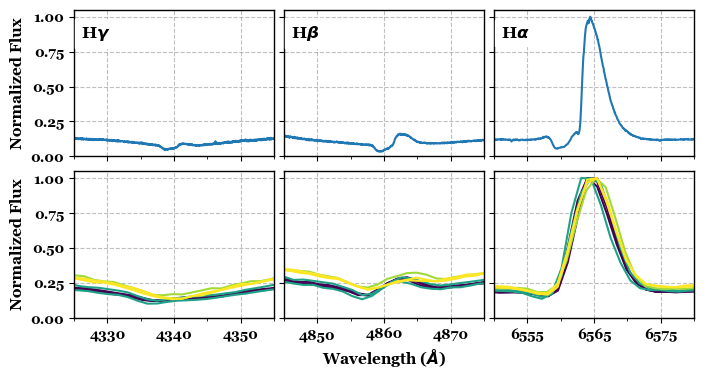

In [360]:
# All Plot

fig, ax = plt.subplots(nrows=2, ncols=3, sharex='col', sharey='row', gridspec_kw={'hspace':0.1, 'wspace':0.05}, figsize=(8, 4))
ax = np.concatenate(ax)

# TRES
ax[0].plot(gamma_wave, gamma_flux/np.max(alpha_flux))
ax[1].plot(beta_wave, beta_flux/np.max(alpha_flux))
ax[2].plot(alpha_wave, alpha_flux/np.max(alpha_flux))

# FAST
t0 = Time(fits.open(files[0])[0].header['MJD'], format='mjd').mjd
t1 = Time(fits.open(files[-1])[0].header['MJD'], format='mjd').mjd
viridis = matplotlib.colormaps['viridis'].resampled(8)

for file in files:
    hdul = fits.open(file)
    hdr = hdul[0].header
    data = hdul[0].data
    flux = data[0][0]

    time = Time(hdr['MJD'], format='mjd').mjd
    
    wv = np.arange(hdr['CRVAL1'], hdr['CRVAL1']+(hdr['CD1_1']*hdr['NAXIS1']), hdr['CD1_1'])
    print(len(wv), len(flux))
    if len(wv) > len(flux): wv = wv[:-1]
    
    ax[3].plot(wv, flux/np.max(flux), c=viridis((time-t0)/(t1-t0)), label=round(time,4))
    ax[4].plot(wv, flux/np.max(flux), c=viridis((time-t0)/(t1-t0)), label=round(time,4))
    ax[5].plot(wv, flux/np.max(flux), c=viridis((time-t0)/(t1-t0)), label=round(time,4))
   
ax[0].text(4326, .85, r'H$\gamma$', fontsize=12, backgroundcolor='w')
ax[1].text(4846, .85, r'H$\beta$', fontsize=12, backgroundcolor='w')
ax[2].text(6551, .85, r'H$\alpha$', fontsize=12, backgroundcolor='w')

ax[0].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[1].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[2].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[3].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[4].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)
ax[5].grid('both','major',c='gray',ls='--', alpha=0.5, zorder=-1)

ax[0].set_xlim(4325, 4355)
ax[0].set_ylim(0, 1.05)
ax[1].set_xlim(4845, 4875)
ax[1].set_ylim(0, 1.05)
ax[2].set_xlim(6550, 6580)
ax[2].set_ylim(0, 1.05)

ax[3].set_ylim(0, 1.05)
ax[4].set_ylim(0, 1.05)
ax[5].set_ylim(0, 1.05)

ax[3].set_xticks([4330, 4340, 4350])
ax[3].set_xticklabels(['4330', '4340', '4350'])
ax[3].set_xticks([4325, 4335, 4345, 4355], minor=True)

ax[4].set_xticks([4850, 4860, 4870])
ax[4].set_xticklabels(['4850', '4860', '4870'])
ax[4].set_xticks([4845, 4855, 4865, 4875], minor=True)

ax[5].set_xticks([6550, 6560, 6570, 6580], minor=True)
ax[5].set_xticks([6555, 6565, 6575], minor=False)

ax[0].set_ylabel('Normalized Flux', fontsize=11)
ax[3].set_ylabel('Normalized Flux', fontsize=11)
ax[4].set_xlabel(r'Wavelength ($\AA$)', fontsize=11)

# ax[3].legend(fontsize=8, loc='upper left')
plt.savefig('/Users/woodml/Documents/X-Ray/AB Aur/figure_hydrogen.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Data Behind Figure

In [7]:
# Create fits hdul
hdul = fits.HDUList()
hdul.append(fits.PrimaryHDU())

# Get TRES Data
file = '/Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/AB-Aur_2012-02-15_07h33m17s_cb.spec.fits'

hdul = fits.open(file)
hdul.info()

hdr = hdul[0].header
hdr['PI'] = hdr['P.I.']
del hdr['P.I.']

all_spec = read_IRAF_spec(file)

for i in [36, 18, 9]:
    wave = all_spec[i].spectral_axis.to('Angstrom').value[4:]
    flux = all_spec[i].flux.value[4:]
    col1 = fits.Column(name='wv(Ang)', format='E', array=wave)
    col2 = fits.Column(name='flux', format='E', array=flux)
    
    cols = fits.ColDefs([col1, col2])
    
    new_hdu = fits.BinTableHDU.from_columns(cols, name='TRES_ORDER', header=hdr)
    hdul.append(new_hdu)

# Get FAST Data
fast = glob.glob('/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/AB Aur/*.fits')
fast.sort(reverse=True)

for file in fast:
    temp = fits.open(file)

    hdr = temp[0].header
    hdr['PI'] = hdr['P.I.']
    del hdr['P.I.']
    
    flux = temp[0].data[0][0]
    wave = np.arange(hdr['CRVAL1'], hdr['CRVAL1']+(hdr['CD1_1']*hdr['NAXIS1']), hdr['CD1_1'])
    
    col1 = fits.Column(name='wv(Ang)', format='E', array=wave)
    col2 = fits.Column(name='flux', format='E', array=flux)

    new_hdu = fits.BinTableHDU.from_columns(fits.ColDefs([col1, col2]), name='FAST_SPECTRUM', header=hdr)
    
    hdul.append(new_hdu)

# Combine
print('\n\n\n')
hdul.info()

hdul.writeto('/Users/woodml/Documents/X-Ray/TaleofTwoStars/AB Aur/dbf_figure_8.fits')

Filename: /Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/AB-Aur_2012-02-15_07h33m17s_cb.spec.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   (2304, 51)   float32   
(51, 2304)
(51, 2304)




Filename: /Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/AB-Aur_2012-02-15_07h33m17s_cb.spec.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  TRES_ORDER    1 PrimaryHDU     266   (2304, 51)   float32   
  1  TRES_ORDER    1 BinTableHDU    272   2300R x 2C   ['E', 'E']   
  2  TRES_ORDER    1 BinTableHDU    272   2300R x 2C   ['E', 'E']   
  3  TRES_ORDER    1 BinTableHDU    272   2300R x 2C   ['E', 'E']   
  4  FAST_SPECTRUM    1 BinTableHDU    139   2681R x 2C   ['E', 'E']   
  5  FAST_SPECTRUM    1 BinTableHDU    139   2681R x 2C   ['E', 'E']   
  6  FAST_SPECTRUM    1 BinTableHDU    139   2681R x 2C   ['E', 'E']   
  7  FAST_SPECTRUM    1 BinTableHDU    139   2681R x 2C   ['E', 'E']   
  8  FAST_SPECTRU